In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

sequence_length = 500 # 模型查看的历史窗口大小
prediction_horizon = 1 # 预测的未来窗口大小
threshold = 0.5

directory = "../datas/test" #设置数据目录
all_items = os.listdir(directory)  #列出目录下所有文件
csv_files = [os.path.join(directory, item) for item in all_items if item.endswith('.csv') and os.path.isfile(os.path.join(directory, item))]  #筛选出CSV文件 
Sample_size = len(csv_files)  #获取样本数量

sequences_data = [] #创建一个空列表，用于存储所有序列的数据
scalers = {} #创建一个空字典，用于存储每个序列对应的标准化器
base_features = ['Voltage', 'Current']
new_features = ['impedance', 'power', 'cumulative_power', 'impedance_diff', 'impedance_rolling_mean', 'impedance_rolling_std', 'impedance_slope_10']
features = base_features + new_features

index = 0
for file in csv_files:
    df = pd.read_csv(file)
    df['impedance'] = df['Voltage'] * 1000 / df['Current'].replace(0, np.nan)
    df['power'] = df['Voltage'] * (df['Current'] / 1000)
    df['cumulative_power'] = (df['power']/1000).cumsum()
    #数据预处理 添加阻抗变化率特征
    df['impedance_diff'] = df['impedance'].diff().fillna(0) #添加一阶差分
    df['impedance_rolling_mean'] = df['impedance'].rolling(window=20, min_periods=1).mean() #滚动均值
    df['impedance_rolling_std'] = df['impedance'].rolling(window=20, min_periods=1).std()  #滚动标准差
    df['impedance_slope_10'] = df['impedance'].diff(10) / 10  #过去 10 个时间点的平均变化率。
    df['impedance_slope_10'] = df['impedance_slope_10'].fillna(0) # 将该列中的所有缺失值（NaN）填充为数字0
    df = df.ffill().bfill()  #缺失值处理先用前向填充，再用后向填充
    #数据预处理 数值归一化
    scaler = StandardScaler() #为当前序列创建一个新的StandardScaler实例
    df.loc[:, features] = scaler.fit_transform(df.loc[:, features]) #对当前序列的指定特征列进行拟合和转换
    scalers[index] = scaler #将当前序列的标准化器保存到字典中，键为序列ID
    index = index+1
    sequences_data.append(df[features + ['Action']].values) #将当前序列的数组数据添加到结果列表中

class MultiSequenceDataset(Dataset):
    #实例化后初始调用
    def __init__(self, sequences_data, sequence_length=100, prediction_horizon=50): 
        self.sequences_data = sequences_data # 输入数据
        self.sequence_length = sequence_length # 模型查看的历史窗口大小
        self.prediction_horizon = prediction_horizon # 预测的未来窗口大小
        self.samples = [] #创建一个空列表
        # for seq_data in sequences_data: #遍历列表里每一条训练数据数组（多维序列）
        n_samples = len(sequences_data) - sequence_length - prediction_horizon + 1 #计算可以生成多少个有效样本：
        for i in range(n_samples): #将n_samples个一个元组 (seq_data, i) 添加到 self.samples 列表中。
            self.samples.append((sequences_data, i)) # 生成待截取序列和开始截取的位置列表
        
    #DataLoader 会自动调用它来知道需要加载多少个样本。
    def __len__(self): 
        return len(self.samples)    #返回数据集中样本的总数，即 self.samples 列表的长度。

    #DataLoader 迭代时，会自动调用它来获取一个样本（特征和标签）。
    def __getitem__(self, idx): 
        seq_data, start_idx = self.samples[idx] #从 self.samples 列表中取出第 idx 个样本对应的原始序列 seq_data 和起始索引 start_idx。
        x = seq_data[start_idx:start_idx + self.sequence_length, :-1]#从 start_idx 开始，截取长度为 sequence_length 的连续时间步。[:, :-1] 表示取所有这些行（时间步），但只取最后一列之前的所有列。
        y_start = start_idx + self.sequence_length #输入序列 x 结束后的下一个时间点。
        y_end = y_start + self.prediction_horizon #y_start 之后的 prediction_horizon 个时间点
        y_window = seq_data[y_start:y_end, -1] # 截取了从 y_start 到 y_end 这个未来窗口内的最后一列，也就是标签列。y_window 是一个一维数组。
        y = 1 if np.any(y_window == 1) else 0
        return torch.FloatTensor(x), torch.FloatTensor([y])

print(f'检索到{Sample_size}个样本')
print(f"原始特征数量: {len(base_features)}")
print(f"扩展后特征数量: {len(features)}")
print(f"序列数量: {len(sequences_data)}")

检索到10个样本
原始特征数量: 2
扩展后特征数量: 9
序列数量: 10


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

model_name = 'TCN'
class Chomp1d(nn.Module):
    def __init__(self, chomp_size): #chomp_size：要修剪的尺寸
        super(Chomp1d, self).__init__()  # 调用父类初始化方法
        self.chomp_size = chomp_size # 保存修剪尺寸为实例变量
        
    def forward(self, x):
        return x[:, :, :-self.chomp_size]

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()

        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)

        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU() #标准的激活函数
        self.dropout1 = nn.Dropout(dropout) #正则化层。

        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(
            self.conv1, self.chomp1, self.relu1, self.dropout1,
            self.conv2, self.chomp2, self.relu2, self.dropout2
        )

        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
        
        self.init_weights()

    # 权重初始化
    def init_weights(self):
        nn.init.normal_(self.conv1.weight, 0, 0.01) #使用均值为0，标准差为0.01的正态分布来初始化卷积层的权重。
        nn.init.normal_(self.conv2.weight, 0, 0.01) # 这是一种常见的初始化策略，目的是在训练开始时让激活值保持在一个合理的范围内，避免梯度消失或爆炸。
        if self.downsample is not None:
            nn.init.normal_(self.downsample.weight, 0, 0.01)

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TCN(nn.Module):
    def __init__(self, input_size, num_channels, kernel_size=3, dropout=0.2):
        super(TCN, self).__init__()
        layers = []
        num_levels = len(num_channels)  #网络的深度由 num_channels 列表的长度决定。
        
        for i in range(num_levels):
            dilation_size = 2 ** i #关键设计！每一层的膨胀系数呈指数增长（1, 2, 4, 8, ...）。
            #通道数管理：
            in_channels = input_size if i == 0 else num_channels[i-1] #第一层的输入通道数等于原始特征数，后续层的输入通道数等于前一层的输出通道数。
            out_channels = num_channels[i]  #当前层的输出通道数。
            
            # 计算padding保持序列长度不变
            padding = (kernel_size - 1) * dilation_size  #为每个块计算特定的填充大小，确保输入输出序列长度一致。
            
            layers += [TemporalBlock(
                in_channels, out_channels, kernel_size, 
                stride=1, dilation=dilation_size, 
                padding=padding, dropout=dropout
            )]
        
        self.network = nn.Sequential(*layers)  #将所有时序块组合成一个顺序模型。
        self.linear = nn.Linear(num_channels[-1], 1)
    #前向传播
    
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        x = x.transpose(1, 2)  # 转换为 (batch_size, input_size, seq_len)
        output = self.network(x) # 输入形状转换
        output = F.adaptive_avg_pool1d(output, 1).squeeze(-1)  
        output = self.linear(output)  # 线性变换：将池化后的特征通过全连接层，得到原始输出。
        output = torch.sigmoid(output) #Sigmoid 激活：将输出压缩到 (0, 1) 区间，表示故障发生的概率。这适合二分类问题。
        
        return output

num_inputs = len(features) # 输入维度
num_channels = [64, 64, 64, 64] # TCN 架构 4 层 TCN，每层 64 个通道
model = TCN(input_size=num_inputs, num_channels=num_channels, kernel_size=3, dropout=0.2)

class FocalLoss(nn.Module):
    """处理类别不平衡的Focal Loss"""
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy(inputs, targets, reduction='none')  #前向传播计算
        pt = torch.exp(-BCE_loss) 
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss  #应用 Focal Loss 调制
        #损失聚合
        if self.reduction == 'mean':
            return torch.mean(F_loss)
        elif self.reduction == 'sum':
            return torch.sum(F_loss)
        else:
            return F_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")
print("加载TCN模型中...")
model.load_state_dict(torch.load("Model_TCN.pkl", map_location=device))
model.to(device)
print("模型加载成功!")

print(f"序列长度: {sequence_length}")
print(f"特征数量: {num_inputs}")

使用设备: cuda
加载TCN模型中...
模型加载成功!
序列长度: 500
特征数量: 9


In [3]:
# 评估模型
def evaluate_model(model, test_loader, device, threshold):
    model.eval()
    y_pred = []
    y_prob = []
    y_true = []
    
    with torch.no_grad():
        for batch_x, batch_y in tqdm(test_loader, desc="已完成", ncols=60):
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            # 前向传播
            outputs = model(batch_x)
            probabilities = outputs.cpu().numpy()
            predictions = (outputs > threshold).float().cpu().numpy()
            
            y_prob.extend(probabilities)
            y_pred.extend(predictions)
            y_true.extend(batch_y.cpu().numpy())
    
    # 转换为numpy数组
    y_prob = np.array(y_prob).flatten()
    y_pred = np.array(y_pred).flatten()
    y_true = np.array(y_true).flatten()
    
    return y_prob, y_pred, y_true

TCN开始模型评估...


已完成: 100%|████████████| 101/101 [00:00<00:00, 197.81it/s]


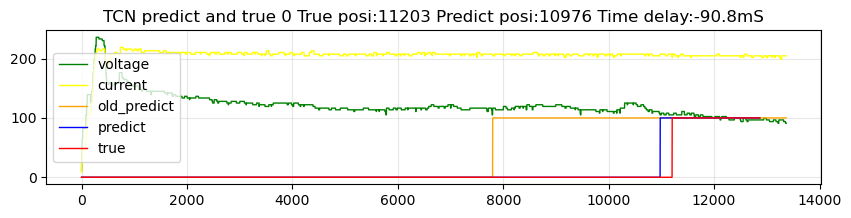

已完成: 100%|██████████████| 93/93 [00:00<00:00, 314.98it/s]


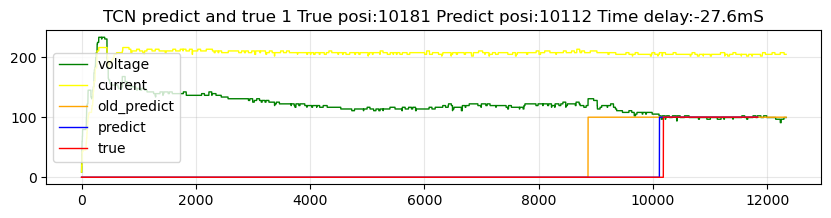

已完成: 100%|██████████████| 86/86 [00:00<00:00, 319.29it/s]


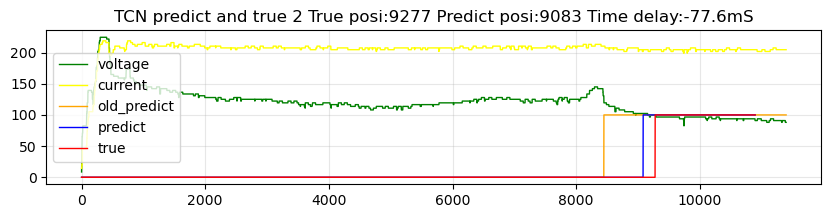

已完成: 100%|████████████| 106/106 [00:00<00:00, 322.23it/s]


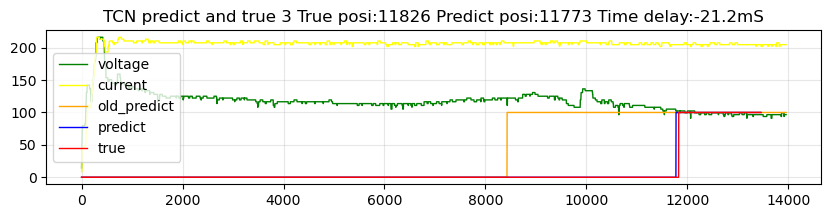

已完成: 100%|██████████████| 70/70 [00:00<00:00, 317.12it/s]


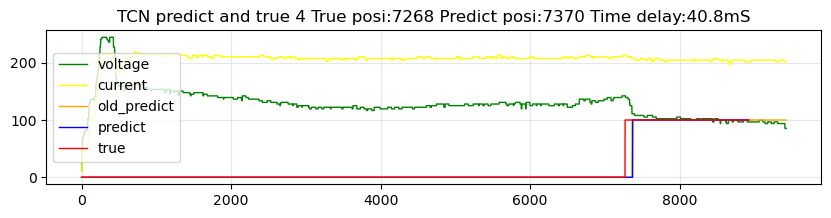

已完成: 100%|██████████████| 92/92 [00:00<00:00, 319.67it/s]


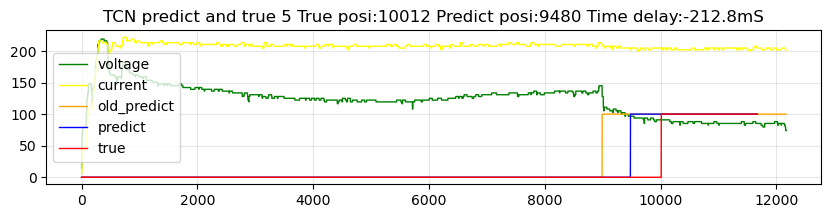

已完成: 100%|████████████| 101/101 [00:00<00:00, 323.26it/s]


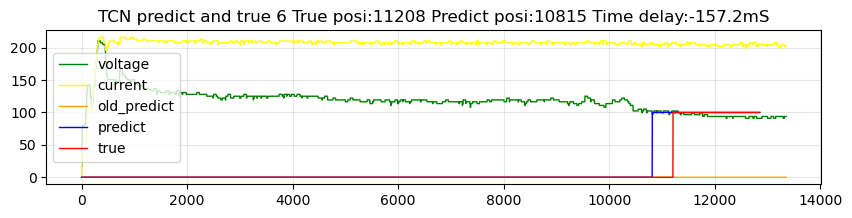

已完成: 100%|████████████| 102/102 [00:00<00:00, 317.88it/s]


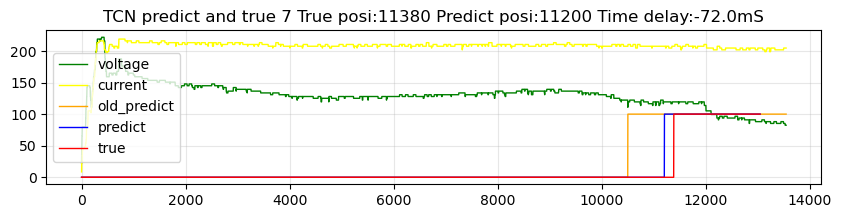

已完成: 100%|██████████████| 76/76 [00:00<00:00, 319.19it/s]


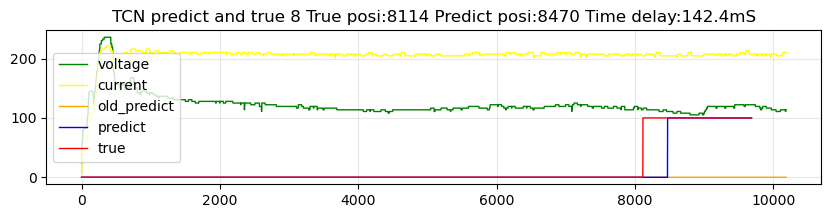

已完成: 100%|██████████████| 91/91 [00:00<00:00, 317.78it/s]


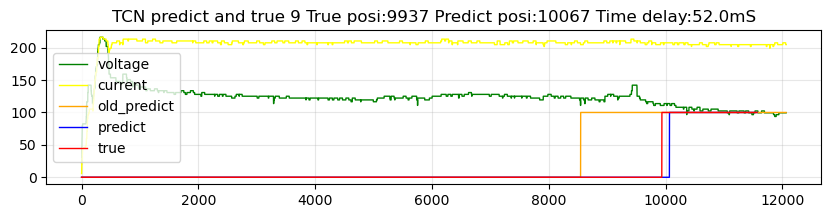

TCN模型评估完成
完成时间20251216_024824
结果保存在Test_results_TCN


In [4]:
import matplotlib.pyplot as plt
import time
from datetime import datetime

print(f'{model_name}开始模型评估...')
delay_result = []
test_sequences = sequences_data

for i in range(Sample_size):
    test_dataset = MultiSequenceDataset(test_sequences[i], sequence_length, prediction_horizon)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    epoch_start_time = time.time()
    probabilities, predictions, targets = evaluate_model(model, test_loader, device, threshold)
    epoch_time = time.time() - epoch_start_time

    # first_one_true = 0
    # first_one_predict = 0
    first_one_true = np.argmax(targets == 1) #找到第一个1的位置
    if targets[first_one_true] == 1:  # 确保确实找到了1
        targets[first_one_true:] = 100
        
    first_one_predict = np.argmax(predictions == 1) #找到第一个1的位置
    if predictions[first_one_predict] == 1:  # 确保确实找到了1
        predictions[first_one_predict:] = 100

    sequence = test_sequences[i]
    
    # 分离特征和标签
    sequence_features = sequence[:, :-1]
    sequence_labels = sequence[:, -1:]
    
    # 使用对应的scaler
    scaler = scalers[i]
    recovered_features = scaler.inverse_transform(sequence_features)
    
    # 重新组合
    recovered_sequence = np.column_stack((recovered_features, sequence_labels))
    
    voltage = recovered_sequence[:, 0]
    current = recovered_sequence[:, 1]
    
    test = recovered_sequence[:, 5]
    test [:7000] = 0
    old_predict = np.zeros(recovered_sequence.shape[0])
    first_old_predict = np.argmax(abs(test) > 50)
    if abs(test[first_old_predict]) > 50:  # 确保确实找到了
        old_predict[first_old_predict:] = 100
    
    plt.figure(figsize=(10, 2))
    plt.plot(voltage, label='voltage', color='green', linewidth=1)
    plt.plot(current, label='current', color='yellow', linewidth=1)
    # plt.plot(test, label='test', color='orange', linewidth=1)
    plt.plot(old_predict, label='old_predict', color='orange', linewidth=1)
    plt.plot(predictions, label='predict', color='blue', linewidth=1)
    plt.plot(targets, label='true', color='red', linewidth=1)
    Delay_time = (first_one_predict - first_one_true)*0.4
    plt.title(f'{model_name} predict and true {i} True posi:{first_one_true} Predict posi:{first_one_predict} Time delay:{Delay_time:.1f}mS')
    plt.legend()  # 显示图例
    plt.grid(True, alpha=0.3)
    save_dir = f'Test_results_{model_name}'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    plt.savefig(os.path.join(save_dir, f'model_evaluation{i}_half.png'), dpi=300, bbox_inches='tight')
    plt.show()
    delay_result.append({
        'index':i,
        'True':first_one_true,
        'diff':first_old_predict,
        f'{model_name}':first_one_predict,
        f'{model_name} Delay':Delay_time,
        f'{model_name} perdict_time mS':epoch_time * 1000 / len(test_sequences[i])
    })
    # print(len(test_sequences[i]))

print(f'{model_name}模型评估完成')
df = pd.DataFrame(delay_result)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"完成时间{timestamp}")
print(f'结果保存在{save_dir}')

In [5]:
print(df[f'{model_name} Delay'].to_string(index=False))

 -90.8
 -27.6
 -77.6
 -21.2
  40.8
-212.8
-157.2
 -72.0
 142.4
  52.0
